In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("D:\\DATOS DISCO DURO PC ANTIGUA 2\\ALVARO\\2026\\predictive-maintenance-industrial\\data\\predictive_maintenance.csv")

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [9]:
df["Target"].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

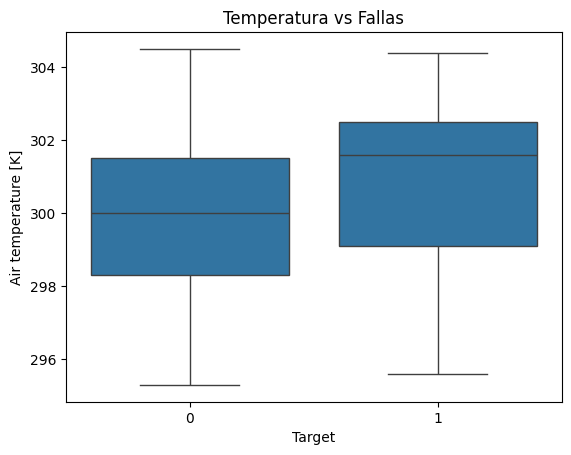

In [12]:
sns.boxplot(data=df,x="Target",y="Air temperature [K]")
plt.title("Temperatura vs Fallas")
plt.show()

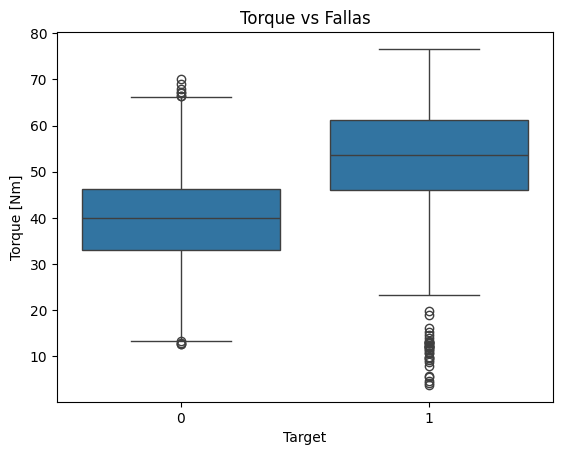

In [13]:
sns.boxplot(data=df,x="Target",y="Torque [Nm]")
plt.title("Torque vs Fallas")
plt.show()

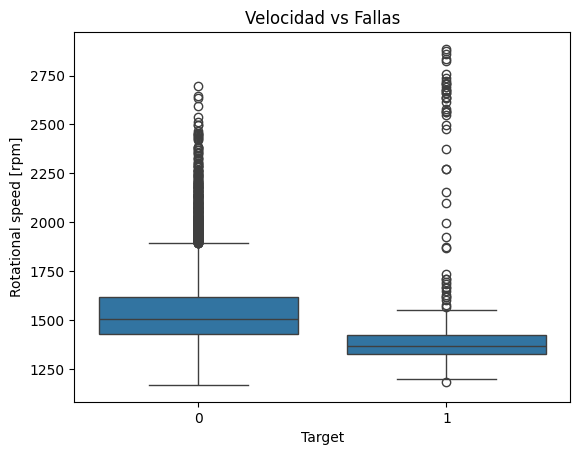

In [14]:
sns.boxplot(data=df, x="Target", y="Rotational speed [rpm]")
plt.title("Velocidad vs Fallas")
plt.show()

In [19]:
df.groupby("Target").mean(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Target,,,,,,
0,5012.878791,299.973999,309.995570,1540.260014,39.629655,106.693717
1,4647.722714,300.886431,310.290265,1496.486726,50.168142,143.781711


- Las fallas están asociadas a cambios en temperatura y torque.
- Se observa que valores extremos incrementan la probabilidad de fallo.
- Se recomienda monitoreo continuo de sensores críticos.

Machine learning

In [31]:
print(df.columns)

Index(['UDI', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type'],
      dtype='object')


In [32]:
df = df.drop(columns=["UDI", "Failure Type"])

In [33]:
X=df.drop("Target",axis=1)
y=df["Target"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier()
modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred = modelo.predict(X_test)

In [37]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1932    7]
 [  26   35]]


|         | Predijo NO | Predijo SÍ |
| ------- | ---------- | ---------- |
| Real NO | ✅ correcto | ❌ error    |
| Real SÍ | ❌ error    | ✅ correcto |


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.83      0.57      0.68        61

    accuracy                           0.98      2000
   macro avg       0.91      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [39]:
import pandas as pd

importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=False)

print(importancias)

Torque [Nm]                0.312897
Rotational speed [rpm]     0.234002
Tool wear [min]            0.162700
Air temperature [K]        0.148302
Process temperature [K]    0.142100
dtype: float64


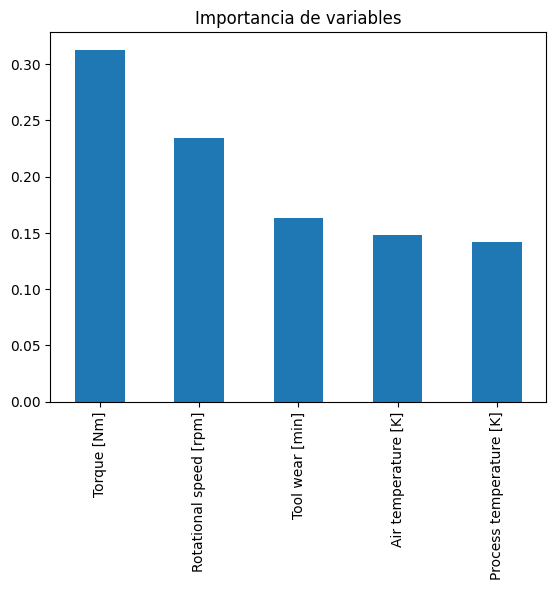

In [40]:
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.show()

Se desarrolló un modelo de Machine Learning para predecir fallas en maquinaria industrial,
identificando variables críticas como torque y temperatura para mantenimiento predictivo.

In [41]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
y_pred = modelo.predict(X_test)

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.88      0.46      0.60        61

    accuracy                           0.98      2000
   macro avg       0.93      0.73      0.80      2000
weighted avg       0.98      0.98      0.98      2000



In [44]:
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


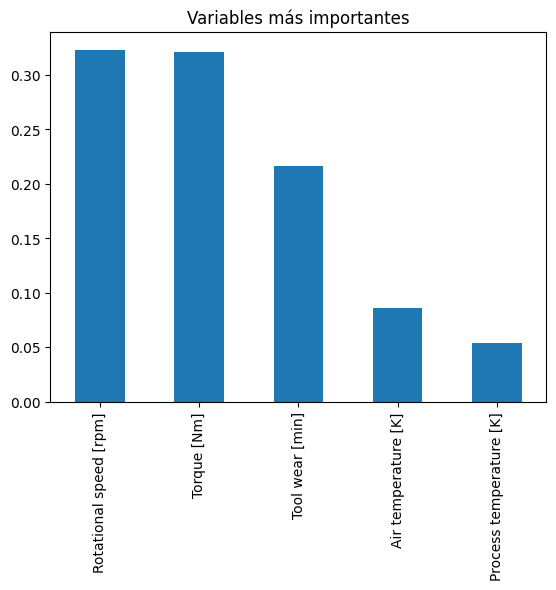

In [45]:
importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=False)

importancias.plot(kind="bar")
plt.title("Variables más importantes")
plt.show()

El modelo fue optimizado utilizando balanceo de clases para mejorar la detección de fallas.
Se identificaron variables críticas como torque y temperatura,
lo que permite implementar estrategias de mantenimiento predictivo.